In [30]:
from google.colab import files
uploaded = files.upload()

Saving The Beatles songs dataset 285x45 v0.csv to The Beatles songs dataset 285x45 v0 (3).csv


In [31]:
!pip install pandas matplotlib numpy mplcyberpunk

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import mplcyberpunk

# Загрузка данных
df = pd.read_csv('The Beatles songs dataset 285x45 v0.csv')

# Кастомная цветовая палитра
colors = ['#925b8b', '#518844', '#2088a8', '#eab500', '#df582c']
plt.rcParams['font.family'] = 'Montserrat'

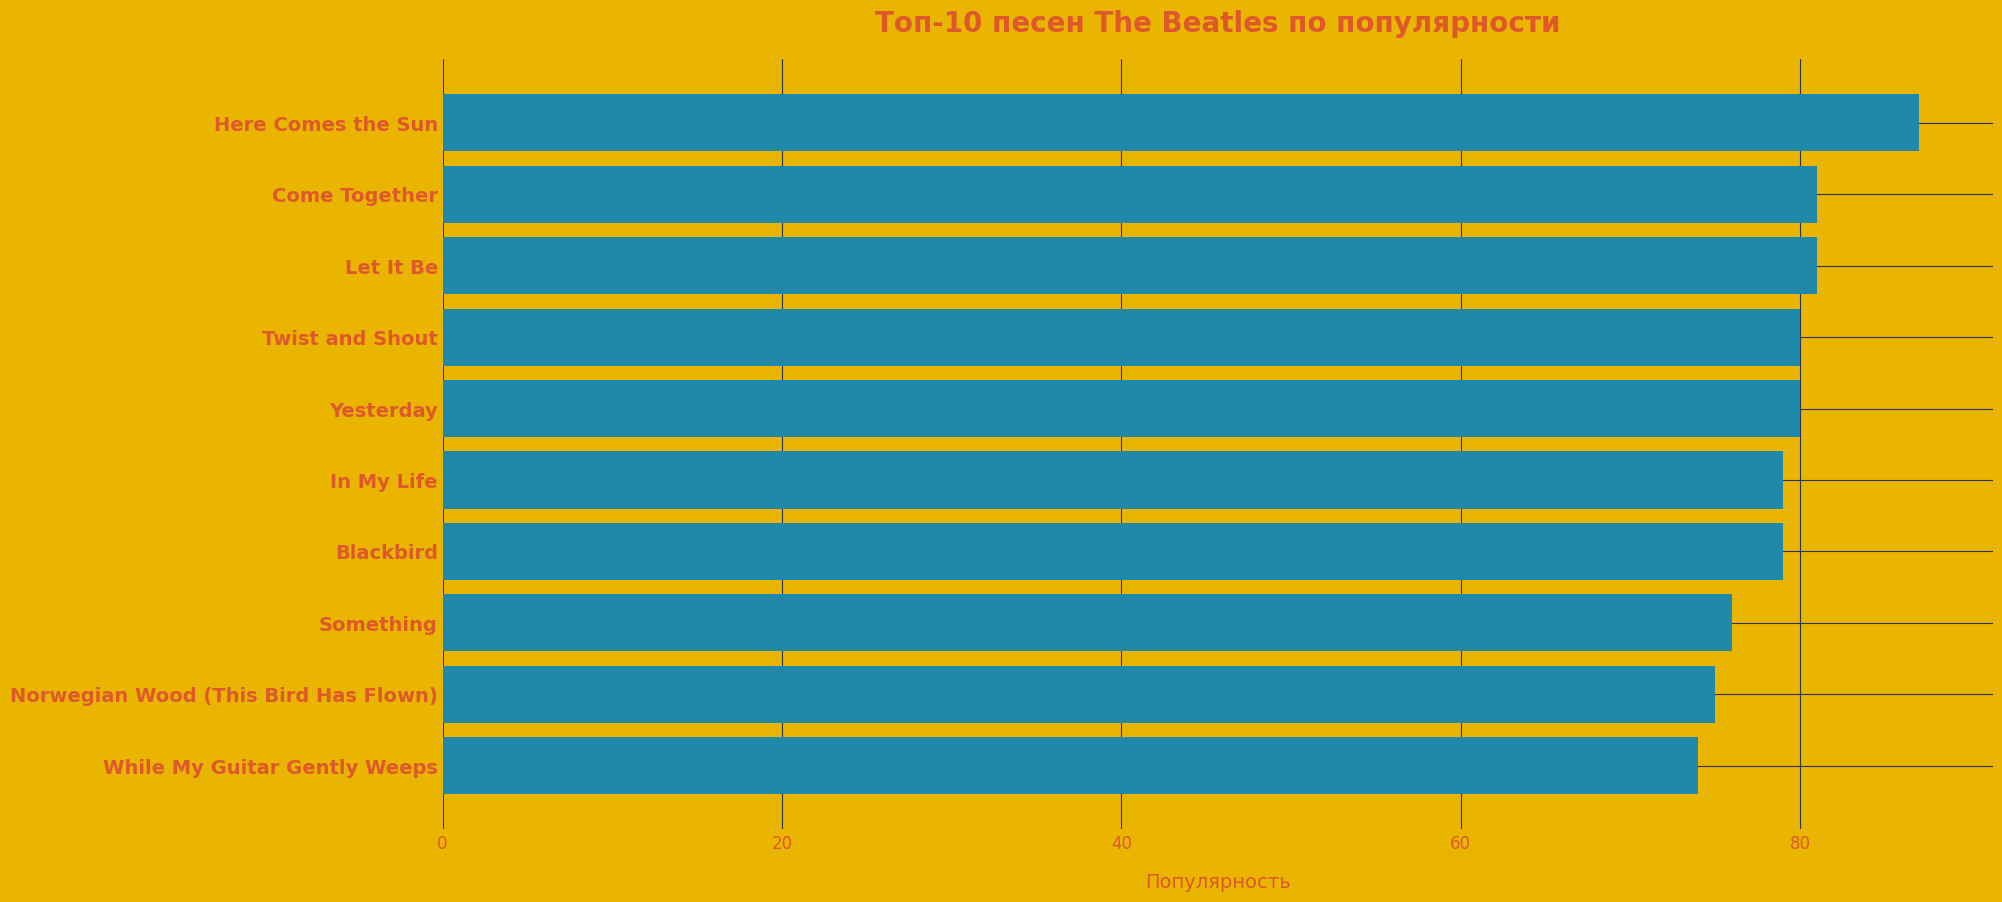

In [17]:
# 1. Топ-10 популярных песен
with plt.style.context('cyberpunk'):

    top_songs = df.sort_values('Popularity', ascending=False).head(10)
    plt.figure(figsize=(20,10))
    bars = plt.barh(top_songs['Title'][::-1], top_songs['Popularity'][::-1], color=colors[2])
    plt.title('Топ-10 песен The Beatles по популярности', fontsize=20, fontweight='bold', pad=20, color = colors[4])
    plt.xlabel('Популярность', fontsize=14, labelpad=15, color = colors[4])
    plt.xticks(fontsize=12, color = colors[4])
    plt.yticks(fontsize=14, color = colors[4], fontweight='bold')
    # Меняем фон
    fig = plt.gcf()
    fig.set_facecolor('#eab500')
    ax = plt.gca()
    ax.set_facecolor('#eab500')


plt.show()


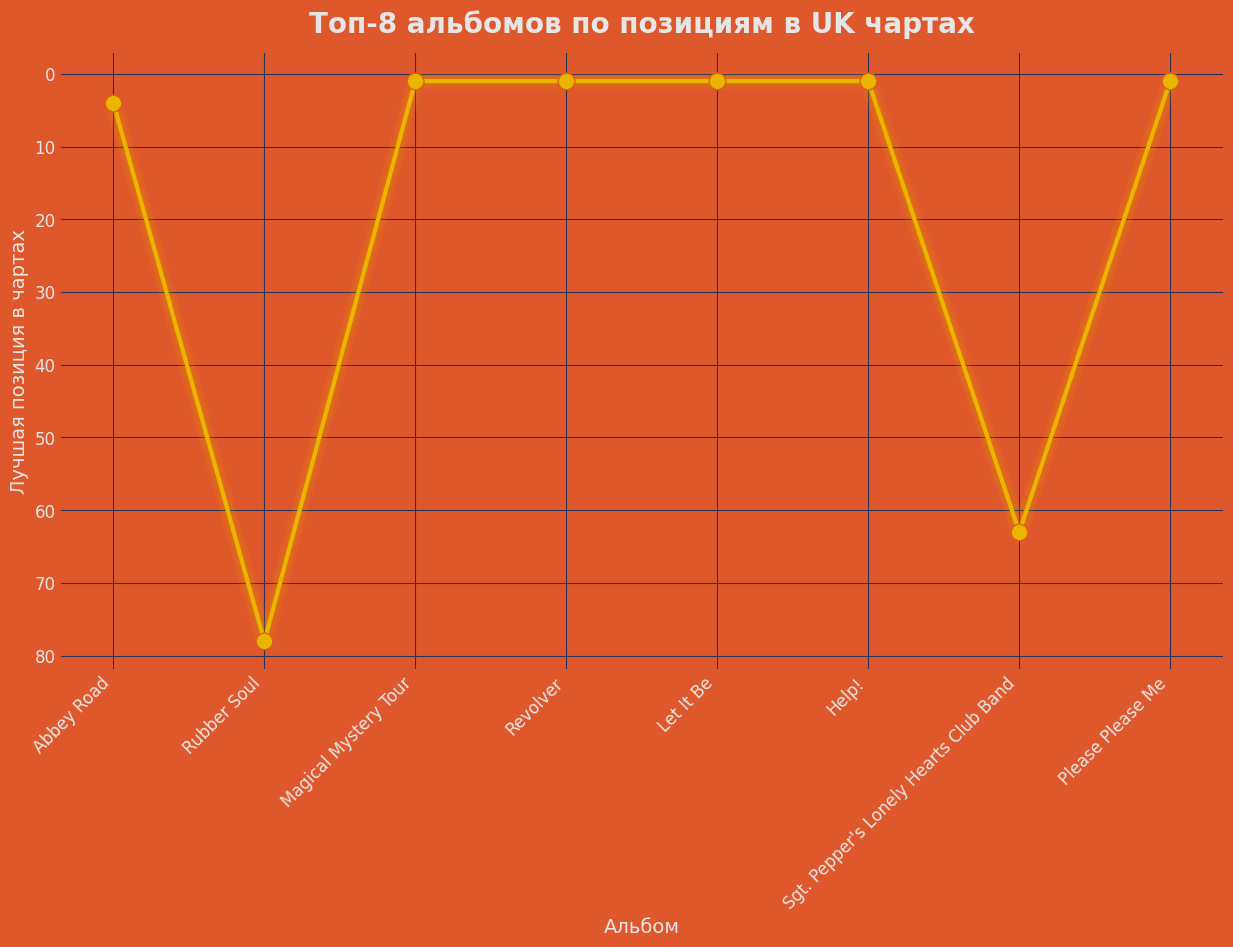

In [18]:
# 2. Успешные альбомы (только ломаная линия)
with plt.style.context('cyberpunk'):
    # Готовим данные: средняя популярность + лучшая позиция в чартах
    album_stats = df.groupby('Album').agg({
        'Popularity': 'mean',
        'Chart position UK (Wikipedia)': 'min'
    }).sort_values('Popularity', ascending=False).head(8)

    plt.figure(figsize=(15, 8))

    # Ломаная линия для позиций в чартах (чем ниже значение - тем выше позиция)
    plt.plot(album_stats.index,
             album_stats['Chart position UK (Wikipedia)'],
             color='#eab500',
             marker='o',
             markersize=12,
             linewidth=3,
             markeredgecolor='#df582c')

    # Инвертируем ось Y для корректного отображения рейтинга
    plt.gca().invert_yaxis()
    plt.title('Топ-8 альбомов по позициям в UK чартах',
             fontsize=20,
             fontweight='bold',
             pad=15)
    plt.xlabel('Альбом', fontsize=14)
    plt.ylabel('Лучшая позиция в чартах', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    mplcyberpunk.make_lines_glow()
    fig = plt.gcf()
    fig.set_facecolor('#df582c')
    ax = plt.gca()
    ax.set_facecolor('#df582c')

plt.show()

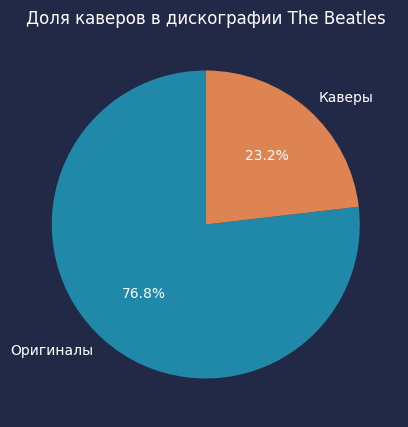

In [40]:
# Подсчет каверов The Beatles
cover_counts = df["Cover"].value_counts().get("Y", 0)
original_counts = len(df) - cover_counts

# Визуализация
plt.figure(figsize=(8, 5))
plt.pie(
    [original_counts, cover_counts],
    labels=["Оригиналы", "Каверы"],
    autopct="%1.1f%%",
    colors=["#2088a8", "#dd8452"],
    startangle=90,
    textprops={'color': 'white'}
)
fig = plt.gcf()
fig.set_facecolor('#222946')
ax = plt.gca()
ax.set_facecolor('#222946')
plt.title("Доля каверов в дискографии The Beatles", color = 'white')

plt.show()

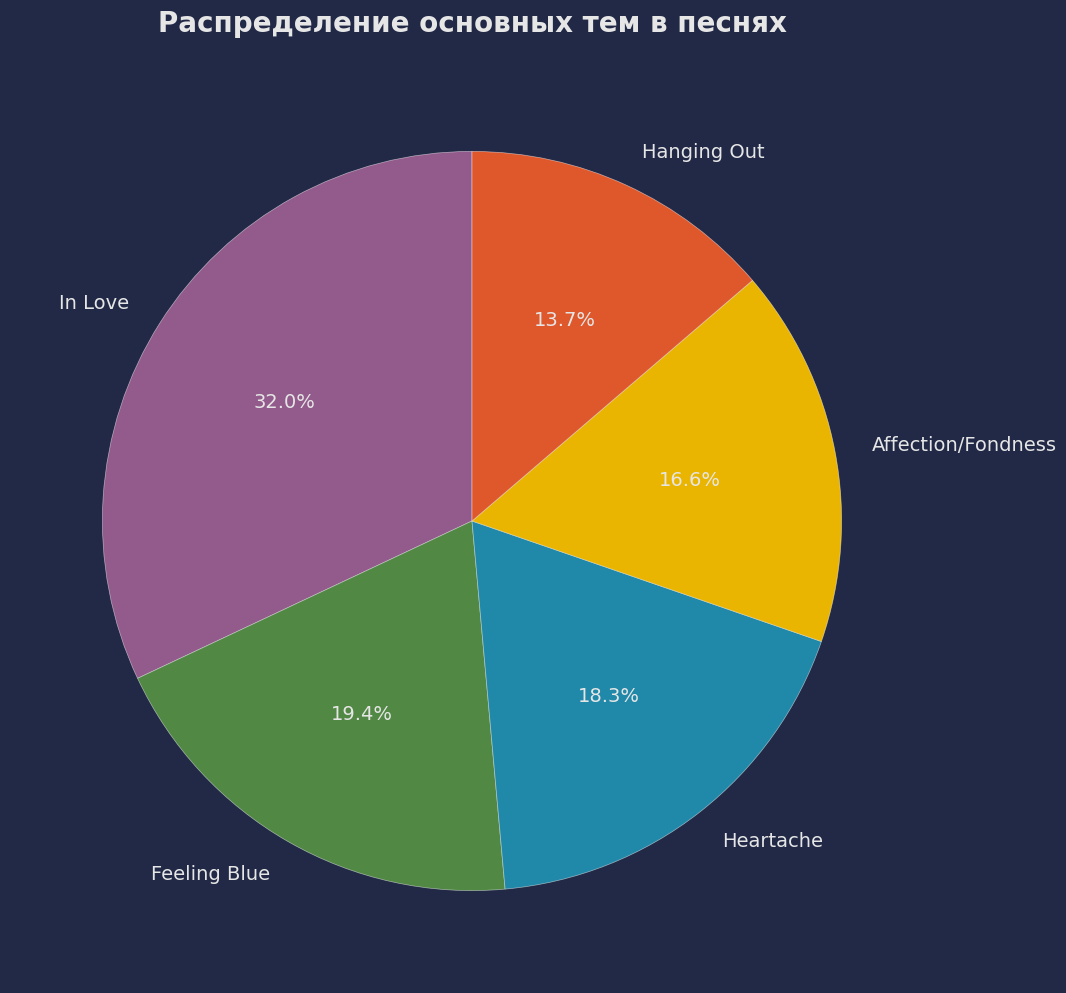

In [7]:
# 4. Популярные темы песен
with plt.style.context('cyberpunk'):
    themes = df['Themes'].dropna().str.split(', ').explode().value_counts().head(5)
    plt.figure(figsize=(12,12))
    wedges, texts, autotexts = plt.pie(themes, labels=themes.index,
                                      autopct='%1.1f%%', startangle=90,
                                      colors=colors, textprops={'fontsize': 14})

    # Добавляем 3D-эффект
    for wedge in wedges:
        wedge.set_edgecolor('#ffffff88')
        wedge.set_linewidth(0.5)

    plt.title('Распределение основных тем в песнях', fontsize=20, fontweight='bold', pad=20)
    mplcyberpunk.add_glow_effects()

plt.show()

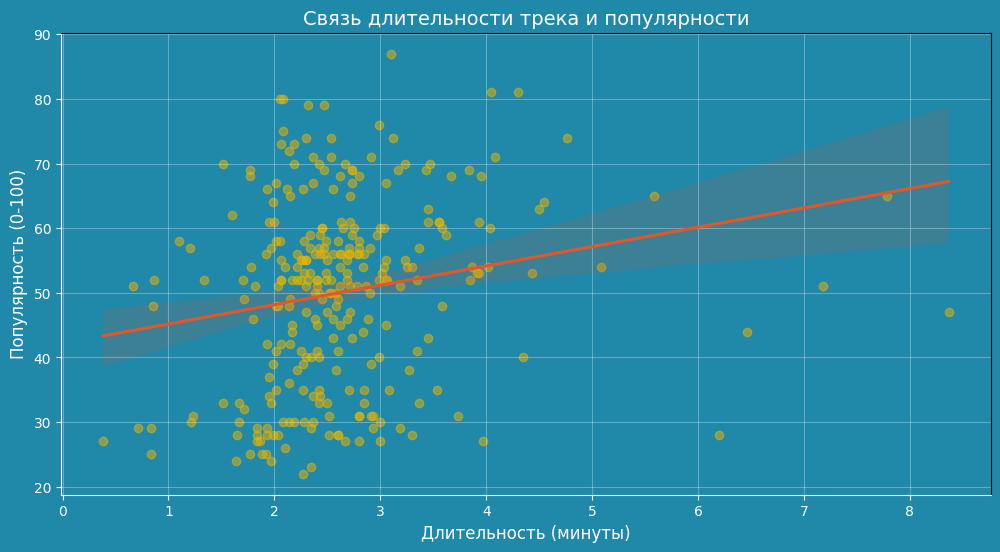

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Конвертация длительности в минуты
df["Duration_min"] = df["Duration"] / 60

# График
plt.figure(figsize=(12, 6))
sns.regplot(
    data=df,
    x="Duration_min",
    y="Popularity",
    scatter_kws={
        "alpha": 0.5,
        "color": "#eab500"  # Желтый (ваш #eab500)
    },
    line_kws={
        "color": "#df582c"  # Красный (ваш #df582c)
    }
)

# Установка цветов фона
plt.gcf().set_facecolor('#2088a8')  # Голубой фон фигуры (ваш #2088a8)
plt.gca().set_facecolor('#2088a8')  # Голубой фон области графика

# Настройка текста
plt.title("Связь длительности трека и популярности", fontsize=14, color='white')
plt.xlabel("Длительность (минуты)", fontsize=12, color='white')
plt.ylabel("Популярность (0-100)", fontsize=12, color='white')

# Настройка осей
ax = plt.gca()
ax.tick_params(colors='white')            # Белые метки на осях
ax.spines['bottom'].set_color('white')    # Белая нижняя ось
ax.spines['left'].set_color('white')      # Белая левая ось

# Сетка
plt.grid(alpha=0.3, color='white')        # Полупрозрачная белая сетка

plt.show()

In [9]:
from google.colab import files
uploaded = files.upload()

Saving Best selling music artists.csv to Best selling music artists.csv


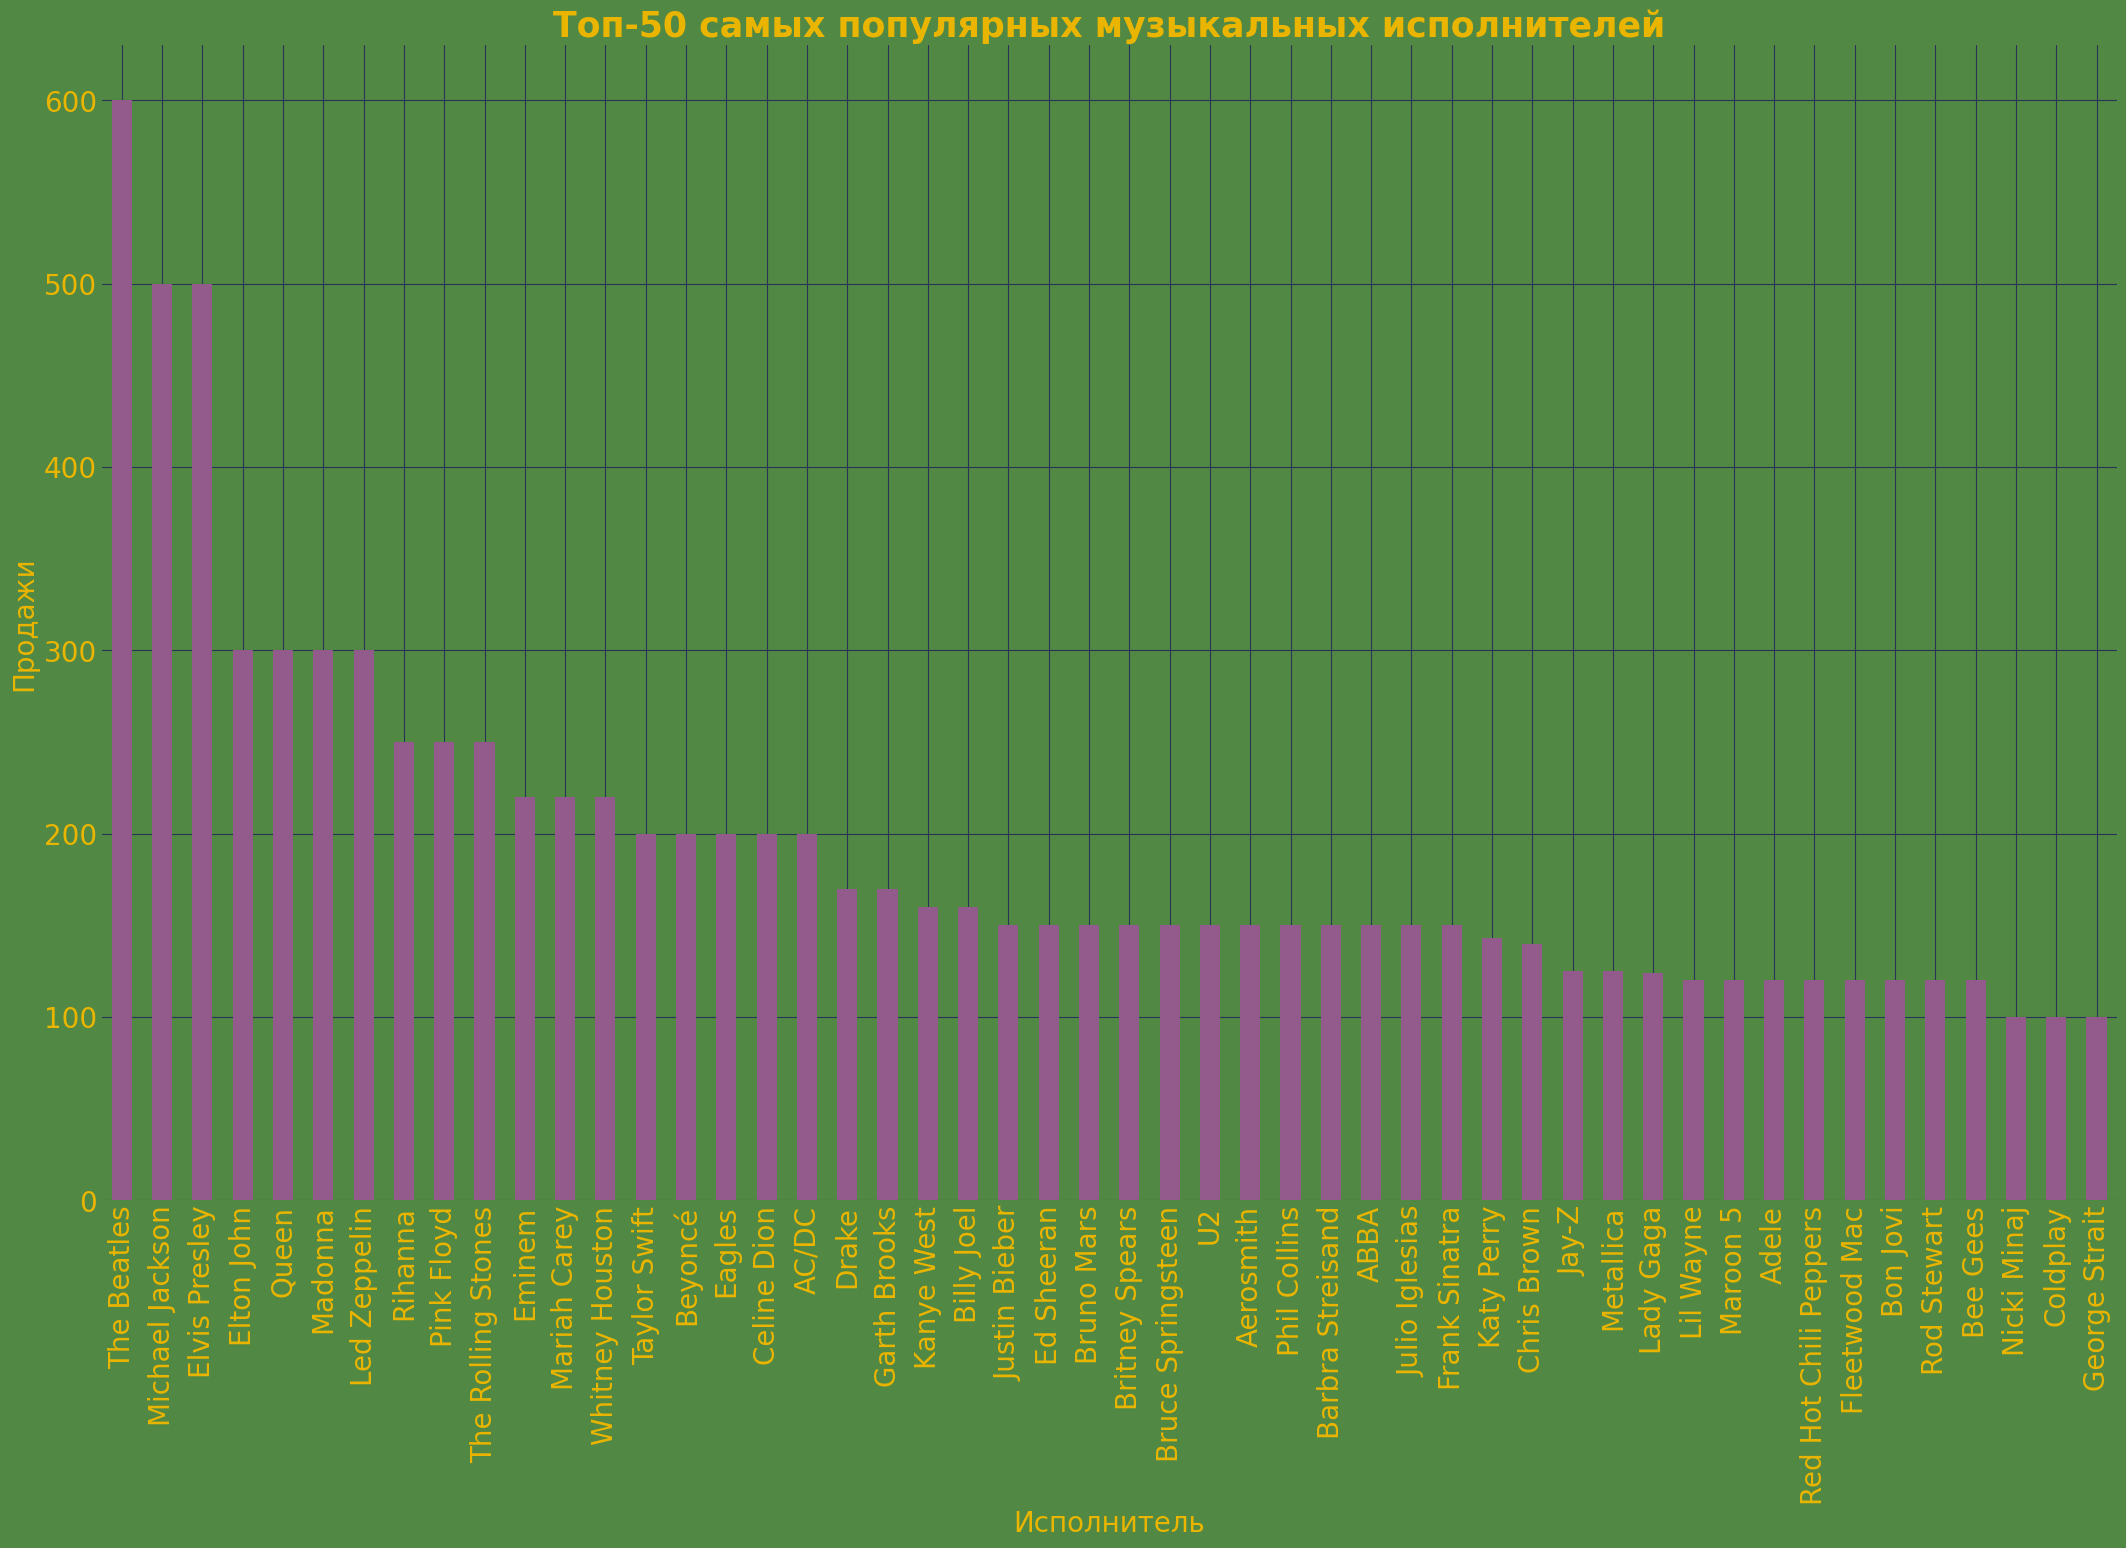

In [26]:
df = pd.read_csv('Best selling music artists.csv')
df['Claimed sales'] = df['Claimed sales'].str.replace(' million', '').astype(int)

plt.rcParams['font.family'] = 'Montserrat'

with plt.style.context('cyberpunk'):
    top_50_artists = df.sort_values(by='Claimed sales', ascending=False).head(50)
    top_50_artists.plot(x='Artist name', y='Claimed sales', kind='bar', figsize=(26,15), legend=False, color = '#925b8b')
    plt.title('Топ-50 самых популярных музыкальных исполнителей', fontsize=25, fontweight='bold', color = '#eab500')
    plt.ylabel('Продажи', fontsize=20, color = '#eab500')
    plt.xlabel('Исполнитель', fontsize=20, color = '#eab500')
    plt.xticks(fontsize=20, color = '#eab500')
    plt.yticks(fontsize=20, color = '#eab500')
    # Меняем фон
    fig = plt.gcf()
    fig.set_facecolor('#518844')
    ax = plt.gca()
    ax.set_facecolor('#518844')

plt.show()